In [2]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
(4897, 8)
(5150, 8)


In [8]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-03 18:33:58,855] A new study created in memory with name: no-name-2c3391b3-457c-427e-bf71-b2f50d56a6ef


[I 2026-02-03 18:33:59,292] Trial 0 finished with value: 18067.997831740446 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 18067.997831740446.
[I 2026-02-03 18:33:59,521] Trial 1 finished with value: 18485.858032736385 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 18067.997831740446.
[I 2026-02-03 18:33:59,887] Trial 2 finished with value: 17962.934941961972 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 2 with value: 17962.934941961972.
[I 2026-02-03 18:34:00,120] Trial 3 finished with value: 18290.6383288965 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 2, 'subsample': 0.6545474901621302, 'colsample_by

Optimal Parameters: {'learning_rate': 0.011615865989246453, 'max_depth': 5, 'subsample': 0.8896896099223679, 'colsample_bytree': 0.8425192044349383}
XGBoost Error: 18158.78246600348
Mean XGBoost Error: 14045.619058912627


1604    62055.0
2241    47415.0
3271    81675.0
693     45660.0
2422    89415.0
         ...   
3709    88725.0
4120    84915.0
1827    39225.0
820     31185.0
4449    87885.0
Name: time_to_next_ev_hr, Length: 980, dtype: float64
[72753.09  52985.66  61696.59  60943.74  60990.297 79954.94  60306.465
 87279.79  57264.42  48116.76  71251.39  53051.14  56344.934 45966.316
 49889.707 59669.633 62199.586 49447.508 59690.312 63160.48  68833.586
 59836.824 68959.2   81131.85  48868.14  64787.53  70977.01  53977.957
 58841.24  60793.39  58596.53  65909.64  57161.39  60482.348 72682.08
 57428.266 57580.61  61563.88  49406.33  59502.273 49210.35  48818.38
 47410.36  52270.633 61206.66  82651.42  67108.39  57433.06  45161.457
 66560.305 45243.758 60101.9   66459.414 76285.3   58505.37  62114.07
 75123.67  85916.82  77672.21  72097.82  71170.53  54798.117 87953.47
 63978.15  48655.695 66481.01  51863.77  67019.836 47147.445 57211.242
 49218.598 47271.773 55446.33  56263.004 38731.55  67975.32  764

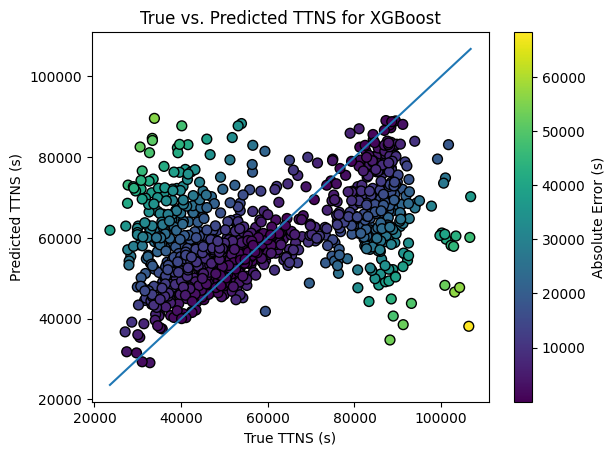

In [5]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

 98%|===================| 963/980 [00:24<00:00]        

XG Boost Drivers: tide_height    4270.141002
form_fac       3066.996257
time_since     2599.243928
slip_size      2243.365570
tide_deriv     2166.103737
high_t_evt     1964.909719
dtype: float64


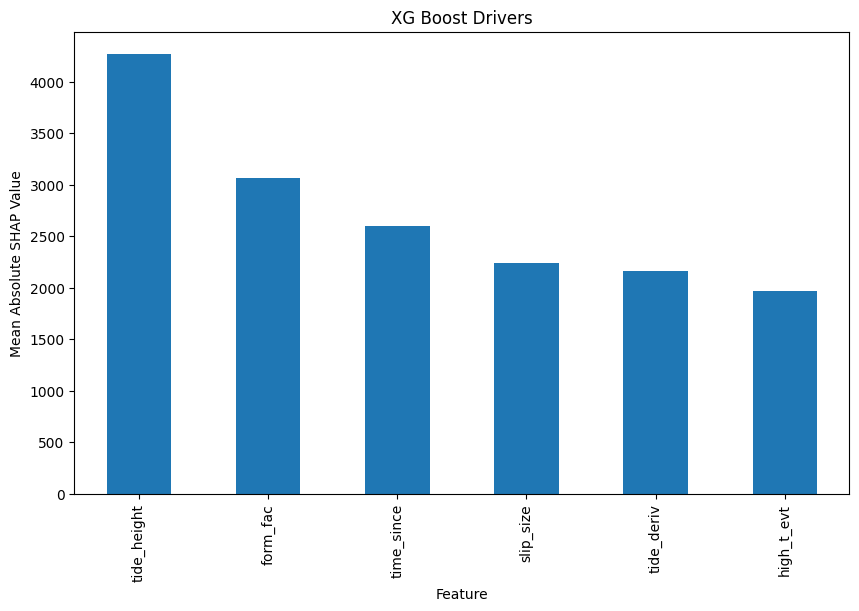

In [6]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
